In [1]:
# Import Library
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments, EarlyStoppingCallback

In [3]:
df = pd.read_csv('/content/drive/MyDrive/uas datmin/email_spam_indo.csv')
df.head()

,Kategori,Pesan
0,spam,Secara alami tak tertahankan identitas perusah...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...
2,spam,Rumah -rumah baru yang luar biasa menjadi muda...
3,spam,4 Permintaan Khusus Pencetakan Warna Informasi...
4,spam,"Jangan punya uang, dapatkan CD perangkat lunak..."


In [4]:
print("Ukuran dataset:", df.shape)
print("Kolom dataset:", list(df.columns))

# Cek missing value
missing_values = pd.DataFrame({
    "Missing_Value": df.isna().sum()
})

print("\nMissing value tiap kolom:")
display(missing_values)

# Cek distribusi label spam/ham
print("\nDistribusi label sebelum drop duplikat:")
display(df["Kategori"].value_counts().to_frame(name="Jumlah"))

Ukuran dataset: (2636, 2)
Kolom dataset: ['Kategori', 'Pesan']

Missing value tiap kolom:


,Missing_Value
Kategori,0
Pesan,0



Distribusi label sebelum drop duplikat:


,Jumlah
Kategori,
spam,1368
ham,1268


In [5]:
def clean_text(text):
    # Mengubah huruf menjadi lowercase
    text = str(text).lower()

    # Menghapus URL
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

    # Menghapus angka, tanda baca, simbol, dan karakter tidak penting
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Menghapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["Pesan_Bersih"] = df["Pesan"].apply(clean_text)

df[["Pesan", "Pesan_Bersih"]].head()

,Pesan,Pesan_Bersih
0,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...
1,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...
2,Rumah -rumah baru yang luar biasa menjadi muda...,rumah rumah baru yang luar biasa menjadi mudah...
3,4 Permintaan Khusus Pencetakan Warna Informasi...,permintaan khusus pencetakan warna informasi t...
4,"Jangan punya uang, dapatkan CD perangkat lunak...",jangan punya uang dapatkan cd perangkat lunak ...


In [6]:
# Encoding Label
df["Label"] = df["Kategori"].map({
    "ham": 0,
    "spam": 1
})

# Split data 80% training, 12% validation, 8% testing
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.40,
    random_state=42,
    stratify=temp_df["Label"]
)

print(f"Jumlah Data Training: {len(train_df)} ({len(train_df) / len(df):.0%})")
print(f"Jumlah Data Validation: {len(val_df)} ({len(val_df) / len(df):.0%})")
print(f"Jumlah Data Testing: {len(test_df)} ({len(test_df) / len(df):.0%})")

Jumlah Data Training: 2108 (80%)
Jumlah Data Validation: 316 (12%)
Jumlah Data Testing: 212 (8%)


In [7]:
# Load Tokenizer IndoBERT
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Custom Dataset class untuk PyTorch
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

# Membuat Objek dataset
train_dataset = EmailDataset(train_df["Pesan_Bersih"], train_df["Label"], tokenizer)
val_dataset = EmailDataset(val_df["Pesan_Bersih"], val_df["Label"], tokenizer)
test_dataset = EmailDataset(test_df["Pesan_Bersih"], test_df["Label"], tokenizer)

print("Jumlah data train:", len(train_dataset))
print("Jumlah data validation:", len(val_dataset))
print("Jumlah data test:", len(test_dataset))

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Jumlah data train: 2108
Jumlah data validation: 316
Jumlah data test: 212


In [8]:
# Load Model IndoBERT untuk klasifikasi 2 label
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

# Fungsi untuk menghitung metrik evaluasi
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# konfigurasi dan hyperparameter
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=10,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs"
)

# Inisialisasi Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.0
        )
    ]
)

print("Memulai training model...")
trainer.train()

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Memulai training model...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=528, training_loss=0.05189454058806101, metrics={'train_runtime': 320.2528, 'train_samples_per_second': 65.823, 'train_steps_per_second': 4.122, 'total_flos': 554638104698880.0, 'train_loss': 0.05189454058806101, 'epoch': 4.0})

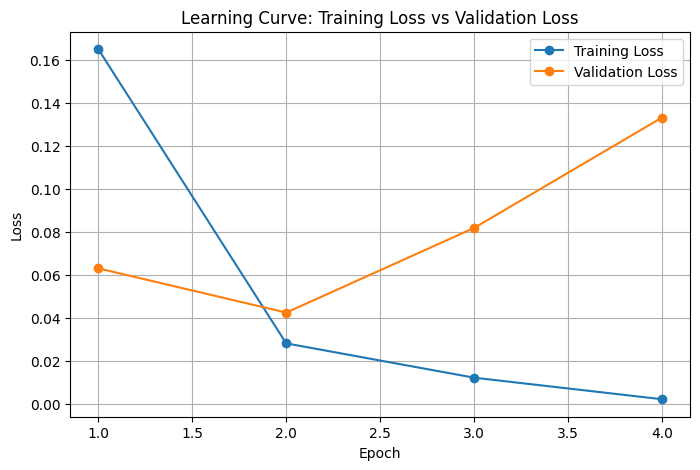

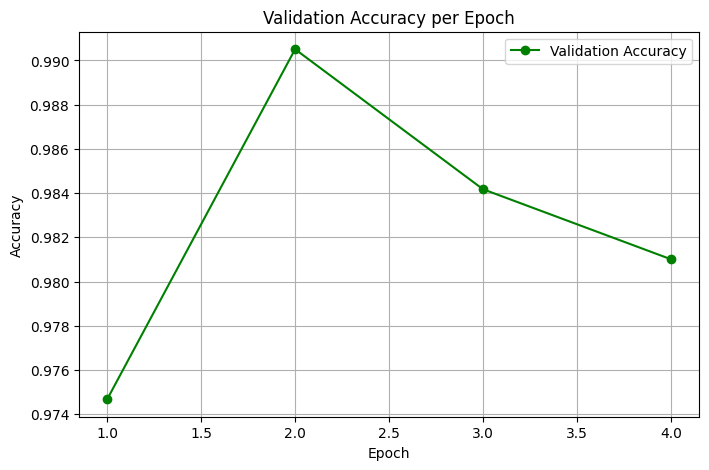

In [9]:
# Visualisasi Learning Curve
log_history = trainer.state.log_history

train_loss = []
eval_loss = []
eval_accuracy = []
epochs_train = []
epochs_eval = []

for log in log_history:
    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])
        epochs_train.append(log["epoch"])

    if "eval_loss" in log and "epoch" in log:
        eval_loss.append(log["eval_loss"])
        eval_accuracy.append(log.get("eval_accuracy"))
        epochs_eval.append(log["epoch"])

# Plot Training Loss dan Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs_train, train_loss, marker="o", label="Training Loss")
plt.plot(epochs_eval, eval_loss, marker="o", label="Validation Loss")
plt.title("Learning Curve: Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs_eval, eval_accuracy, marker="o", color="green", label="Validation Accuracy")
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Hasil Evaluasi pada Data Testing


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.002217,0.099395,4,0.981132,1.000000,0.963636,0.981481


{'eval_loss': 0.0993952751159668, 'eval_accuracy': 0.9811320754716981, 'eval_precision': 1.0, 'eval_recall': 0.9636363636363636, 'eval_f1': 0.9814814814814815}


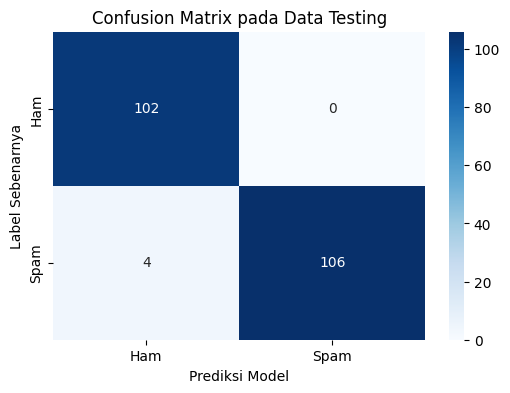

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan tokenizer berhasil disimpan di folder './indobert-spam-model'


In [10]:
# Evaluasi pada Data Testing
print("Hasil Evaluasi pada Data Testing")

test_results = trainer.evaluate(test_dataset)
print(test_results)

# Prediksi label untuk Confusion Matrix
predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=-1)
y_true = predictions.label_ids

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix pada Data Testing")
plt.xlabel("Prediksi Model")
plt.ylabel("Label Sebenarnya")
plt.show()

# Menyimpan model dan tokenizer
model.save_pretrained("./indobert-spam-model")
tokenizer.save_pretrained("./indobert-spam-model")

print("Model dan tokenizer berhasil disimpan di folder './indobert-spam-model'")